# Spatial profiles and Fourier transforms

In this work, the perturbation considered is a localized oscillatory Gaussian excitation,

$$
\Big.\Psi\big(r_\star\big)\Big|_{t=0}=A\,\exp\!\Bigg[-\frac{\big(r_\star-r_0\big)^2}{2\sigma^2}\Bigg]\cos\!\bigg[\nu\big(r_\star-r_0\big)\bigg].
$$

where $A$ is the amplitude, $r_0$ is the location of the perturbation, $\sigma$ its characteristic width and $\nu$ a parameter that acts as the driving frequency of the perturbation. Notice that $\nu$ introduces a preferred frequency scale which modulates the Gaussian pulse across the spatial domain $r_\star$.

## Initial data construction

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Grid
N = 1024
r_min, r_max = -50, 50
r = np.linspace(r_min, r_max, N)
dr = r[1] - r[0]

# Perturbation parameters
A = 1.0
r0 = 0.0
sigma = 5.0

# Driving frequencies
nus = np.array([0.000, 0.373, 0.555])

We construct a family of initial data by fixing $(A, r_0, \sigma)$ and varying the parameter $\nu$.

The Gaussian envelope localizes the perturbation in space, while the cosine term introduces an oscillatory structure with characteristic frequency $\nu$.

In [3]:
# Gaussian envelope
gaussian = A * np.exp(-(r - r0)**2 / (2 * sigma**2))

# Signals for different ν (vectorized)
signals = gaussian * np.cos(np.outer(nus, r - r0))

## Spatial profile

We first visualize the perturbation in real space. The effect of increasing $\nu$ is to introduce progressively faster oscillations within the same Gaussian envelope.

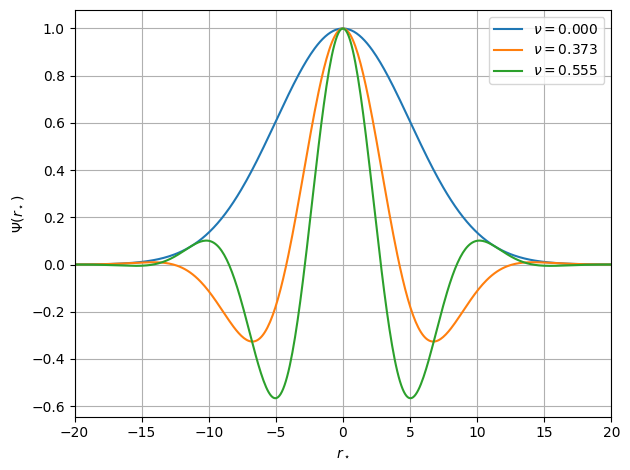

In [4]:
plt.figure()

for i, (s, nu) in enumerate(zip(signals, nus)):
    plt.plot(r, s, label=fr"$\nu={nu:.3f}$")

plt.xlim(-20, 20)
plt.xlabel(r"$r_\star$")
plt.ylabel(r"$\Psi(r_\star)$")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

## Spectral analysis

To understand the frequency content of the perturbation, we compute its Fourier transform.

Due to the oscillatory factor, we expect peaks centered around $\omega = \pm \nu$, modulated by the Fourier transform of the Gaussian envelope.

To improve frequency resolution, we employ zero-padding.

In [5]:
Npad = 8 * N

fft_vals = np.abs(
    np.fft.fftshift(
        np.fft.fft(signals, n=Npad, axis=1),
        axes=1
    )
)

# Normalize each spectrum
fft_vals /= fft_vals.max(axis=1, keepdims=True)

# Frequency axis
omega = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(Npad, dr))

The Fourier transform of a Gaussian-modulated cosine consists of two symmetric peaks located at $\omega = \pm \nu$.

Their width is controlled by $\sigma$, reflecting the uncertainty relation between spatial localization and frequency spread.

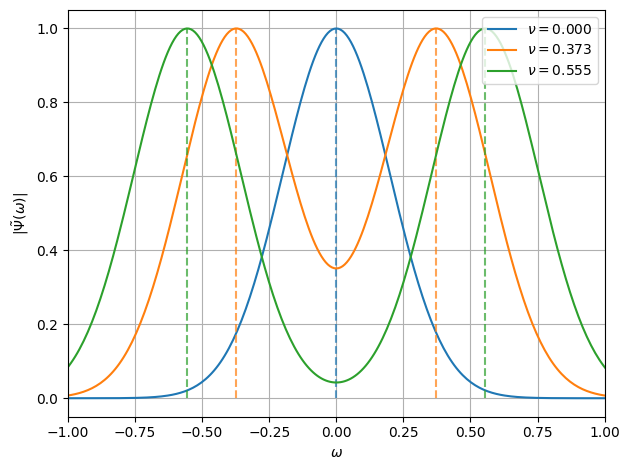

In [6]:
plt.figure()

for i, (f, nu) in enumerate(zip(fft_vals, nus)):
    line, = plt.plot(omega, f, label=fr"$\nu={nu:.3f}$")
    plt.vlines(0 if nu==0 else [-nu, nu], 0, 1,
               linestyles='--', alpha=0.7,
               colors=line.get_color())

plt.xlim(-1, 1)
plt.xlabel(r"$\omega$")
plt.ylabel(r"$|\tilde{\Psi}(\omega)|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()